# Notebook 04 Revenue & Financial Analysis
## Goal: Understand revenue trends, profitability and financial patterns
**Business Value:** Identify peak revenue periods, pricing patterns and financial health

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

master = pd.read_csv("../data/processed/master_clean.csv")

master['order_purchase_timestamp'] =pd.to_datetime(master['order_purchase_timestamp'], errors='coerce')

master['order_month'] = master['order_purchase_timestamp'].dt.to_period('M')


print("DATA LOADED")
print(f" Shape: {master.shape[0]:,} rows x {master.shape[1]} columns")


DATA LOADED
 Shape: 119,143 rows x 29 columns


##  QUESTION 1 Monthly Revenue Trend


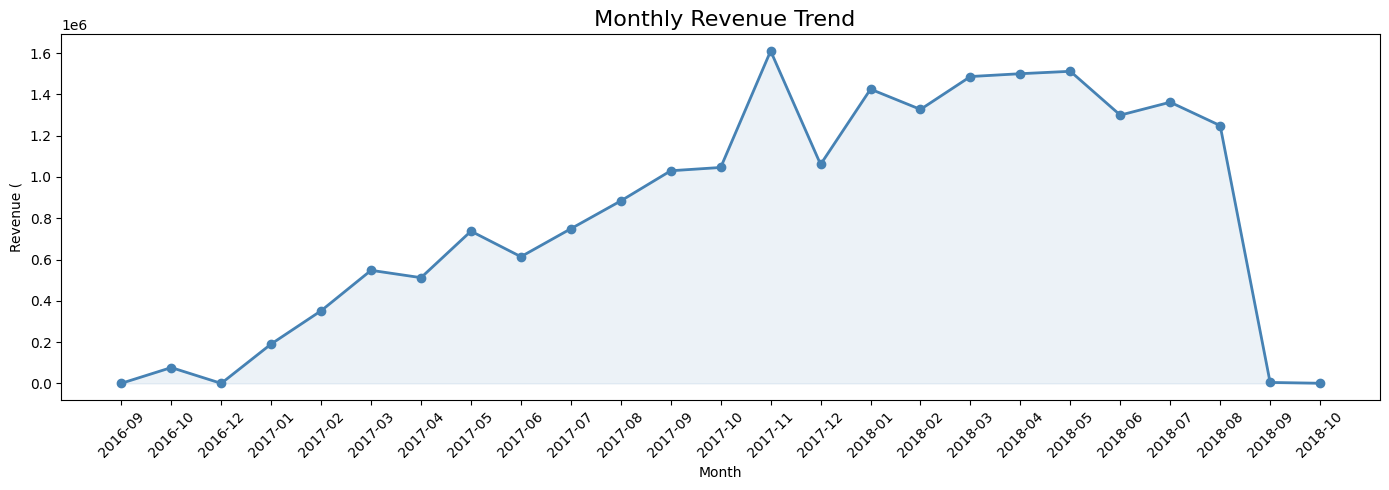

 Total Revenue :  20,579,664.01
 Peak Month    : 2017-11
 Peak Revenue  :  1,610,581.21


In [2]:


monthly_revenue = master.groupby('order_month')['payment_value'].sum().reset_index()
monthly_revenue.columns = ['month', 'revenue']
monthly_revenue['month'] = monthly_revenue['month'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly_revenue['month'], monthly_revenue['revenue'],
         marker='o', color='steelblue', linewidth=2)
plt.fill_between(range(len(monthly_revenue)),
                 monthly_revenue['revenue'],
                 alpha=0.1, color='steelblue')
plt.title(' Monthly Revenue Trend', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Revenue (')
plt.xticks(range(len(monthly_revenue)),
           monthly_revenue['month'], rotation=45)
plt.tight_layout()
plt.savefig('../visuals/11_monthly_revenue.png', dpi=150)
plt.show()

peak_month = monthly_revenue.loc[monthly_revenue['revenue'].idxmax(), 'month']
total_rev = monthly_revenue['revenue'].sum()
print(f" Total Revenue :  {total_rev:,.2f}")
print(f" Peak Month    : {peak_month}")
print(f" Peak Revenue  :  {monthly_revenue['revenue'].max():,.2f}")

## Average Order Value (AOV) Trend



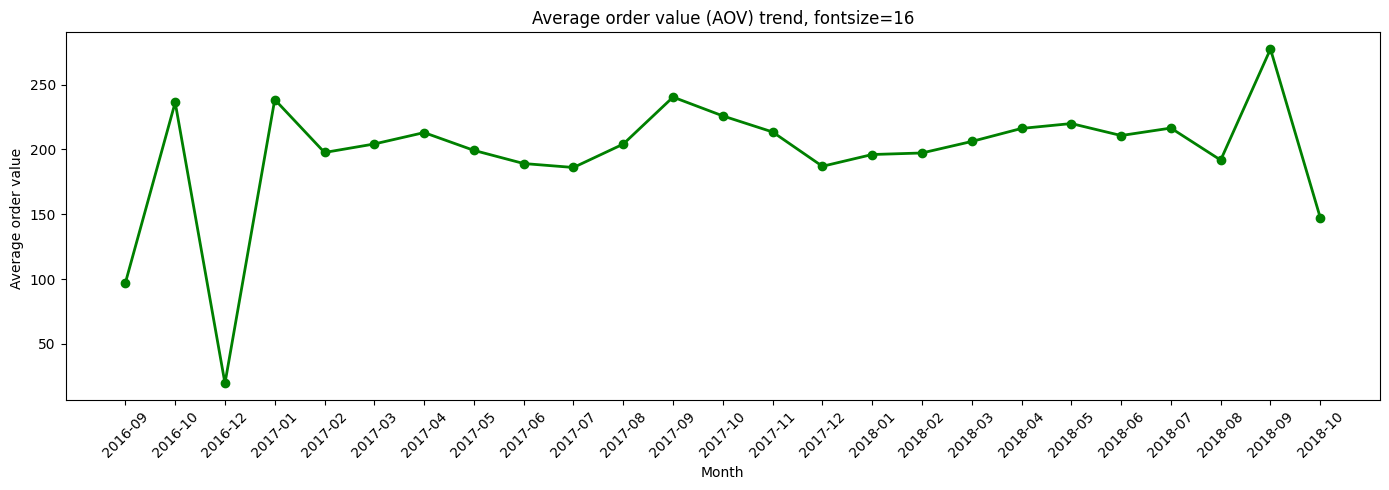

 Overall Average Order Value:  206.95


In [3]:
order_values = master.groupby('order_id')['payment_value'].sum().reset_index()
order_values.columns =['order_id','order_total']

order_values = order_values.merge(master[['order_id','order_month']].drop_duplicates(),
                                  on='order_id', how='left')

order_values['order_month']=order_values['order_month'].astype(str)

monthly_aov = order_values.groupby('order_month')['order_total'].mean().reset_index()
monthly_aov.columns =['month','aov']

plt.figure(figsize=(14,5))
plt.plot(monthly_aov['month'],monthly_aov['aov'],
         marker='o', color='green', linewidth=2)
plt.title('Average order value (AOV) trend, fontsize=16')
plt.xlabel('Month')
plt.ylabel('Average order value ')
plt.xticks(rotation =45)
plt.tight_layout()
plt.savefig('../visuals/12_AOV_trend.png', dpi=150)
plt.show()

overall_aov = order_values['order_total'].mean()
print(f" Overall Average Order Value:  {overall_aov:,.2f}")

## QUESTION 3 Freight Cost Analysis


 Average freight value : R$ 20.10
 Average freight % of order: 21.5%


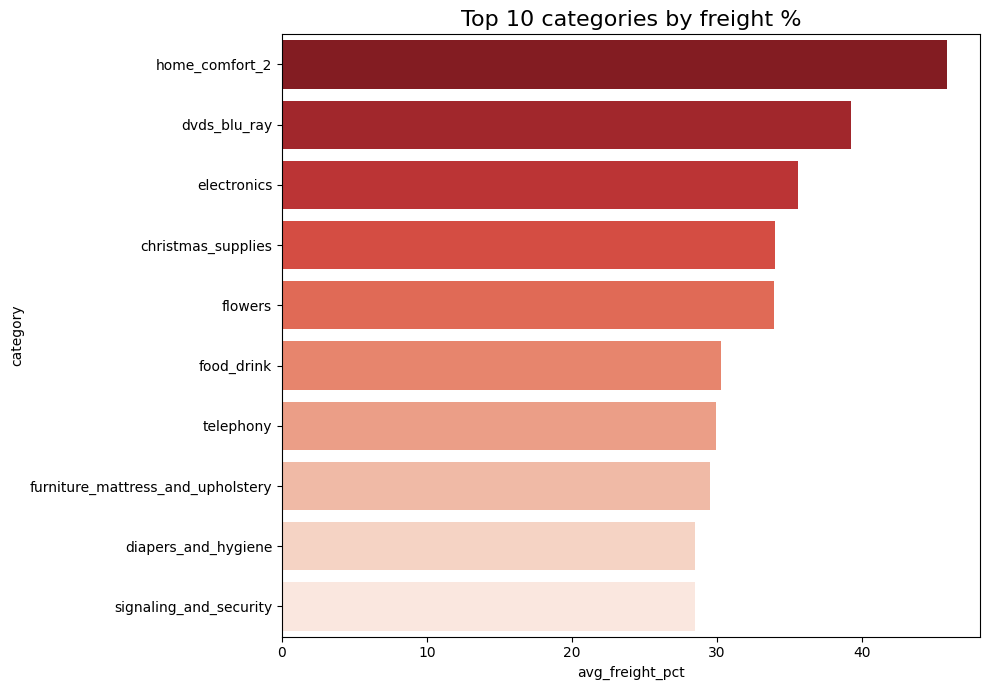

In [4]:
master['freight_pct'] = (master['freight_value'] / (master['price'] + master['freight_value'])) * 100

freight_data =master[(master['price']>0) & (master['freight_value']>0) ].copy()

avg_freight_pct =freight_data['freight_pct'].mean()
avg_freight_val = freight_data['freight_value'].mean()

print(f" Average freight value : R$ {avg_freight_val:,.2f}")
print(f" Average freight % of order: {avg_freight_pct:,.1f}%")

category_freight = freight_data.groupby('product_category_name_english')['freight_pct'].mean().reset_index()
category_freight.columns= ['category','avg_freight_pct']
category_freight = category_freight.sort_values('avg_freight_pct', ascending=False).head(10)


plt.figure(figsize=(10,7))
sns.barplot(data=category_freight, y='category', x='avg_freight_pct' ,palette='Reds_r')
plt.title('Top 10 categories by freight %', fontsize=16)
plt.xlabel=('Average Freight as % of order values')
plt.ylabel=('Category')
plt.tight_layout()
plt.savefig('../visuals/13_freight_analysis.png',dpi=150)
plt.show()

## Question 4 Revenue by Payment Type

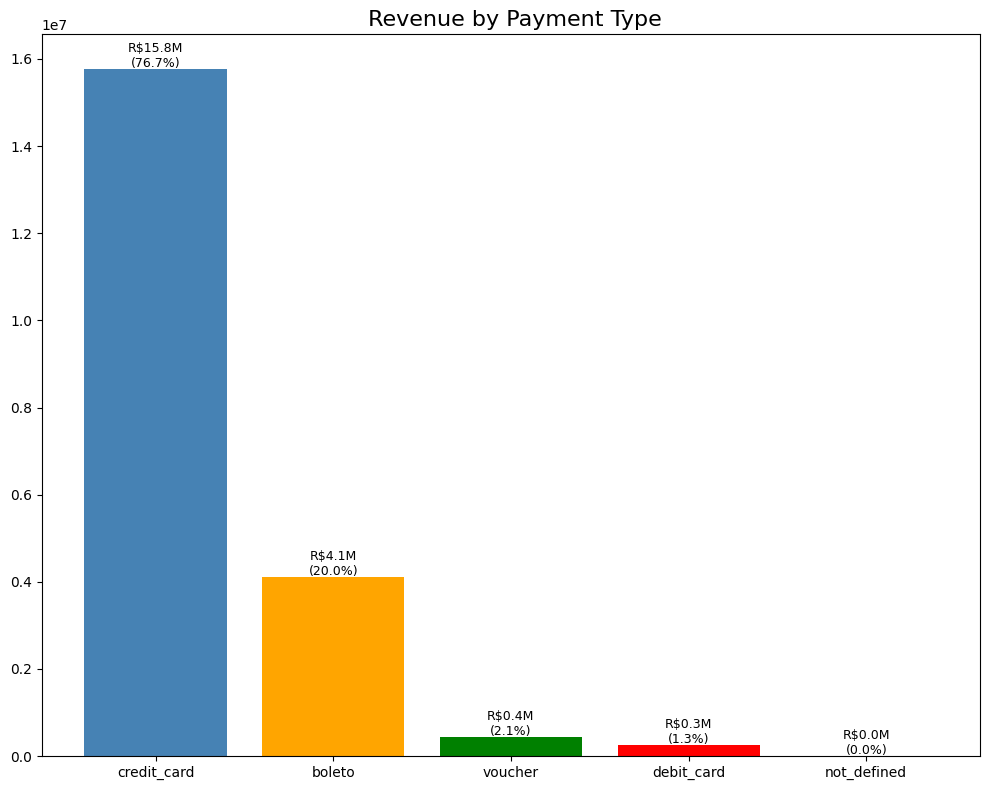

Revenue by Payment Type:
  credit_card     → R$ 15,775,451 (76.7%)
  boleto          → R$ 4,110,921 (20.0%)
  voucher         → R$ 435,918 (2.1%)
  debit_card      → R$ 257,375 (1.3%)
  not_defined     → R$ 0 (0.0%)


In [5]:
# ── QUESTION 4 — Revenue by Payment Type ──────
# 🎯 Which payment method drives most revenue?

payment_revenue = master.groupby('payment_type')['payment_value'].sum().reset_index()
payment_revenue.columns = ['payment_type', 'revenue']
payment_revenue = payment_revenue.sort_values('revenue', ascending=False)

total = payment_revenue['revenue'].sum()

plt.figure(figsize=(10, 8))
colors = ['steelblue', 'orange', 'green', 'red']
bars = plt.bar(payment_revenue['payment_type'],
               payment_revenue['revenue'], color=colors)
plt.title(' Revenue by Payment Type', fontsize=16)
plt.xlabel=('Payment Type')
plt.ylabel=('Total Revenue (R$)')

for bar, rev in zip(bars, payment_revenue['revenue']):
    pct = rev / total * 100
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50000,
             f'R${rev/1e6:.1f}M\n({pct:.1f}%)',
             ha='center', fontsize=9)


plt.tight_layout()
plt.savefig('../visuals/14_payment_revenue.png', dpi=150)
plt.show()

print("Revenue by Payment Type:")
for _, row in payment_revenue.iterrows():
    print(f"  {row['payment_type']:15s} → R$ {row['revenue']:,.0f} ({row['revenue']/total*100:.1f}%)")

## Question 5 Installment Behavior

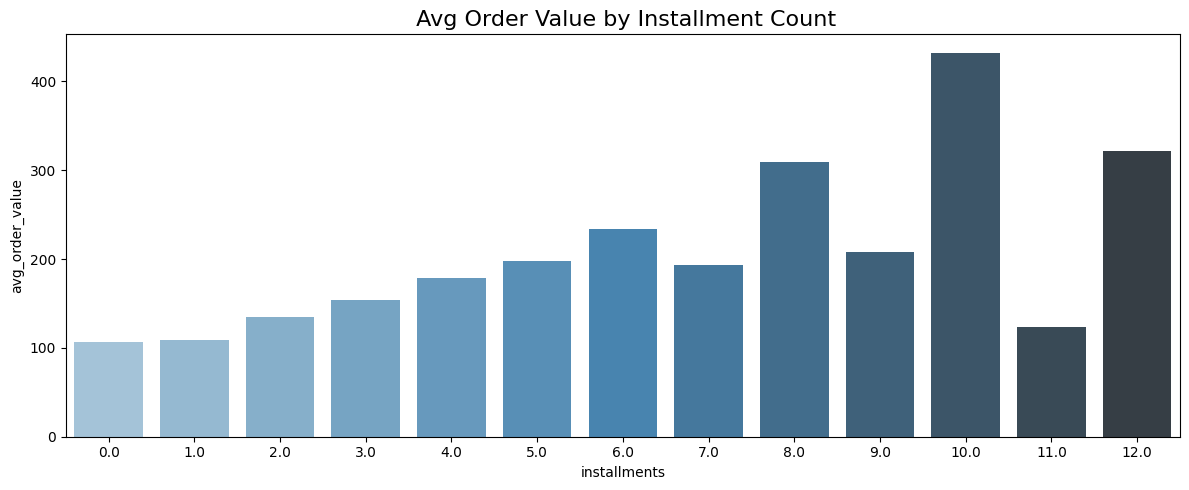

 Highest AOV at 10 installments
 Average value  : R$ 431.35
 Overall CC avg : R$ 179.72


In [6]:

cc_orders = master[master['payment_type'] == 'credit_card'].copy()

installment_aov = cc_orders.groupby(
    'payment_installments')['payment_value'].mean().reset_index()
installment_aov.columns = ['installments', 'avg_order_value']

# Keep only reasonable installment counts
installment_aov = installment_aov[installment_aov['installments'] <= 12]

plt.figure(figsize=(12, 5))
sns.barplot(data=installment_aov, x='installments',
            y='avg_order_value', palette='Blues_d')
plt.title(' Avg Order Value by Installment Count', fontsize=16)
plt.xlabel=('Number of Installments')
plt.ylabel=('Average Order Value (R$)')
plt.tight_layout()
plt.savefig('../visuals/15_installments.png', dpi=150)
plt.show()

best = installment_aov.loc[installment_aov['avg_order_value'].idxmax()]
print(f" Highest AOV at {int(best['installments'])} installments")
print(f" Average value  : R$ {best['avg_order_value']:,.2f}")
print(f" Overall CC avg : R$ {cc_orders['payment_value'].mean():,.2f}")

##  Question 6 Revenue by Day of Week

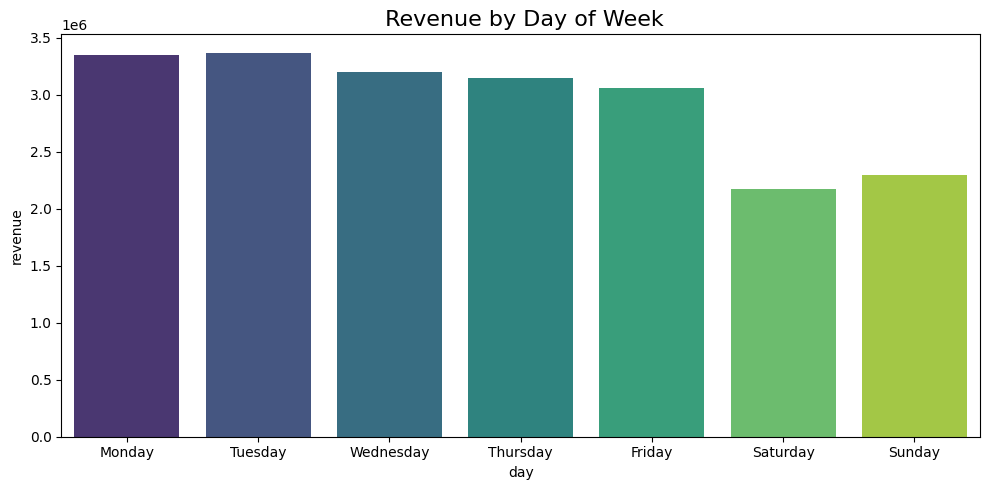

 Highest revenue day : Tuesday
 Lowest revenue day  : Saturday


In [13]:


master['order_day'] = master['order_purchase_timestamp'].dt.day_name()

day_order = ['Monday','Tuesday','Wednesday',
             'Thursday','Friday','Saturday','Sunday']

daily_revenue = master.groupby('order_day')['payment_value'].sum().reset_index()
daily_revenue.columns = ['day', 'revenue']
daily_revenue['day'] = pd.Categorical(
    daily_revenue['day'], categories=day_order, ordered=True)
daily_revenue = daily_revenue.sort_values('day')

plt.figure(figsize=(10, 5))
sns.barplot(data=daily_revenue, x='day',
            y='revenue', palette='viridis')
plt.title(' Revenue by Day of Week', fontsize=16)
plt.xlabel=('Day')
plt.ylabel=('Total Revenue ')
plt.tight_layout()
plt.savefig('../visuals/16_daily_revenue.png', dpi=150)
plt.show()

best_day = daily_revenue.loc[daily_revenue['revenue'].idxmax(), 'day']
worst_day = daily_revenue.loc[daily_revenue['revenue'].idxmin(), 'day']
print(f" Highest revenue day : {best_day}")
print(f" Lowest revenue day  : {worst_day}")

##  Question 7 — Order Value Distribution

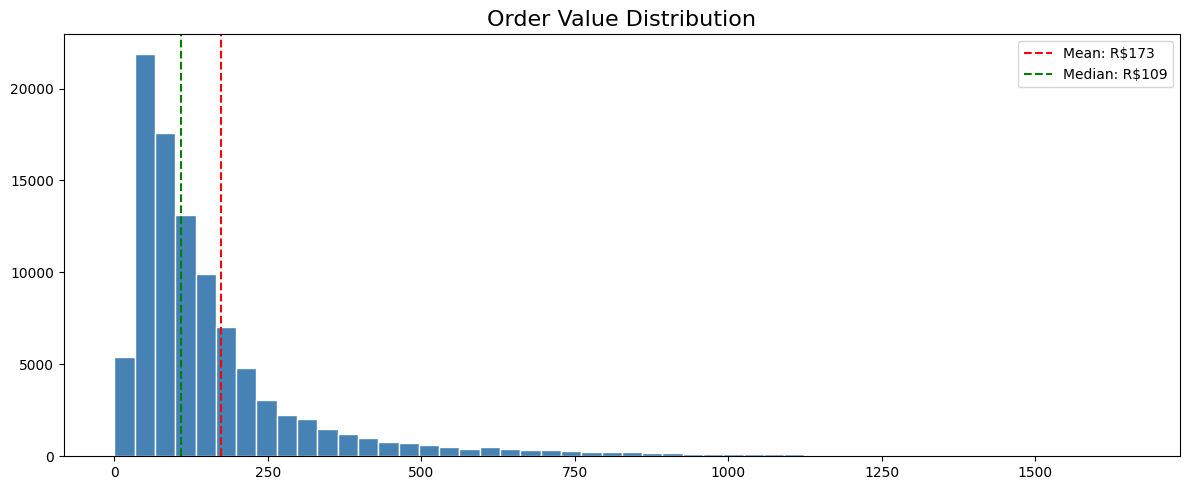

 ORDER VALUE SEGMENTS:
  Below R$100      : 45,313 orders (45.6%)
  R$100 to R$500   : 47,006 orders (47.3%)
  Above R$500      : 7,122 orders (7.2%)


In [8]:
#QUESTION 7  Order Value Distribution
# Get order level totals
order_totals = master.groupby('order_id')['payment_value'].sum().reset_index()
order_totals.columns = ['order_id', 'order_total']

# Remove outliers above 99th percentile for clean visualization
p99 = np.percentile(order_totals['order_total'], 99)
clean_orders = order_totals[order_totals['order_total'] <= p99]

plt.figure(figsize=(12, 5))
plt.hist(clean_orders['order_total'], bins=50,
         color='steelblue', edgecolor='white')
plt.title('Order Value Distribution', fontsize=16)
plt.xlabel=('Order Value (R$)')
plt.ylabel=('Number of Orders')
plt.axvline(clean_orders['order_total'].mean(), color='red',
            linestyle='--', label=f"Mean: R${clean_orders['order_total'].mean():,.0f}")
plt.axvline(clean_orders['order_total'].median(), color='green',
            linestyle='--', label=f"Median: R${clean_orders['order_total'].median():,.0f}")
plt.legend()
plt.tight_layout()
plt.savefig('../visuals/17_order_distribution.png', dpi=150)
plt.show()

# Segment breakdown
low = len(order_totals[order_totals['order_total'] < 100])
mid = len(order_totals[(order_totals['order_total'] >= 100) &
                        (order_totals['order_total'] < 500)])
high = len(order_totals[order_totals['order_total'] >= 500])
total_orders = len(order_totals)

print(f" ORDER VALUE SEGMENTS:")
print(f"  Below R$100      : {low:,} orders ({low/total_orders*100:.1f}%)")
print(f"  R$100 to R$500   : {mid:,} orders ({mid/total_orders*100:.1f}%)")
print(f"  Above R$500      : {high:,} orders ({high/total_orders*100:.1f}%)")

## Question 8 — Financial Summary Report

In [10]:
# QUESTION 8 Financial Summary Report

order_totals2 = master.groupby('order_id')['payment_value'].sum()
avg_freight = master['freight_value'].mean()
avg_freight_pct = master['freight_pct'].mean()
top_payment = master['payment_type'].value_counts().index[0]
cc_data = master[master['payment_type'] == 'credit_card']
avg_installments = cc_data['payment_installments'].mean()

print("=" * 55)
print("  FINANCIAL SUMMARY REPORT — OLIST 2016-2018")
print("=" * 55)
print(f"""
     ORDERS & REVENUE
   Total Revenue          : R$ {master['payment_value'].sum():>15,.2f}
   Total Orders           : {master['order_id'].nunique():>15,}
   Average Order Value    : R$ {order_totals2.mean():>15,.2f}
   Median Order Value     : R$ {order_totals2.median():>15,.2f}

     FREIGHT METRICS
   Average Freight Value  : R$ {avg_freight:>15,.2f}
   Avg Freight % of Order :    {avg_freight_pct:>14.1f}%

     PAYMENT BEHAVIOR
   Most Used Payment      : {top_payment:>15}
   Avg CC Installments    : {avg_installments:>15.1f}
""")
print("=" * 55)

  FINANCIAL SUMMARY REPORT — OLIST 2016-2018

     ORDERS & REVENUE
   Total Revenue          : R$   20,579,664.01
   Total Orders           :          99,441
   Average Order Value    : R$          206.95
   Median Order Value     : R$          110.24

     FREIGHT METRICS
   Average Freight Value  : R$           20.03
   Avg Freight % of Order :              21.4%

     PAYMENT BEHAVIOR
   Most Used Payment      :     credit_card
   Avg CC Installments    :             3.6

